In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import os
import sys
!{sys.executable} -m pip install matplotlib
from copy import deepcopy
sys.path.insert(1, os.path.abspath(os.path.join(os.getcwd(), '../')))

In [3]:
import gillespy3d_pp as gillespy2

In [4]:
gillespy2.__file__

'/Users/anisgolriz/Desktop/GillesPy3D/simulation_lib/gillespy3d_pp/__init__.py'

In [5]:
def Dimerization(parameter_values=None):
    # First call the gillespy2.Model initializer.
    model = gillespy2.Model(name="Dimerization")

    # Define parameters for the rates of creation and dissociation.
    k_c = gillespy2.Parameter(name='k_c', expression=0.005)
    k_d = gillespy2.Parameter(name='k_d', expression=0.08)
    model.add_parameter([k_c, k_d])

    # Define variables for the molecular species representing M & D.
    m = gillespy2.Species(name='monomer', initial_value=30)
    d = gillespy2.Species(name='dimer',   initial_value=0)
    model.add_species([m, d])

    # The list of reactants and products for a Reaction object are
    # each a Python dictionary in which the dictionary keys are
    # Species objects and the values are stoichiometries of the
    # species in the reaction.
    r_c = gillespy2.Reaction(name="r_creation", rate=k_c,
                             reactants={m:2}, products={d:1})
    r_d = gillespy2.Reaction(name="r_dissociation", rate=k_d,
                             reactants={d:1}, products={m:2})
    model.add_reaction([r_c, r_d])

    # Set the timespan for the simulation.
    tspan = gillespy2.TimeSpan.linspace(t=100, num_points=101)
    model.timespan(tspan)
    return model

In [6]:
model = Dimerization()

TypeError: TimeSpan.linspace() got an unexpected keyword argument 't'

In [ ]:
dir(gillespy2)

In [7]:
import matplotlib.pyplot as plt
#Temp graph for accuracy checks
sim = gillespy2.Simulation(model, "SSA")
#sim = gillespy2.Simulation(model, NumPySSASolver())
all_trajs = []
num_traj = 10
end_t = 100;
for traj in range(num_traj):
    sim.reset() # reset the simulation after each run
    dt=.1
    times = []
    monomer = []
    dimer = []
    
    while sim.get_time() < end_t:
        t = sim.get_time()
        times.append(t)
        monomer.append(sim.get_species('monomer'))
        dimer.append(sim.get_species('dimer'))
        #make f string
        #print('traj',traj,' t:',sim.get_time(),' Substrate:',sim.get_species('Substrate'))
        sim.run_until(sim.get_time()+dt);
    all_trajs.append((times, monomer, dimer))
plt.figure(figsize=(8,5))

for times, monomer, dimer in all_trajs:
    plt.plot(times, monomer, 'r', alpha=0.3)
    plt.plot(times, dimer,   'b', alpha=0.3)

plt.xlabel("Time")
plt.ylabel("Molecule Count")
plt.title("Dimerization SSA")
plt.grid(True)
plt.show()


NameError: name 'model' is not defined

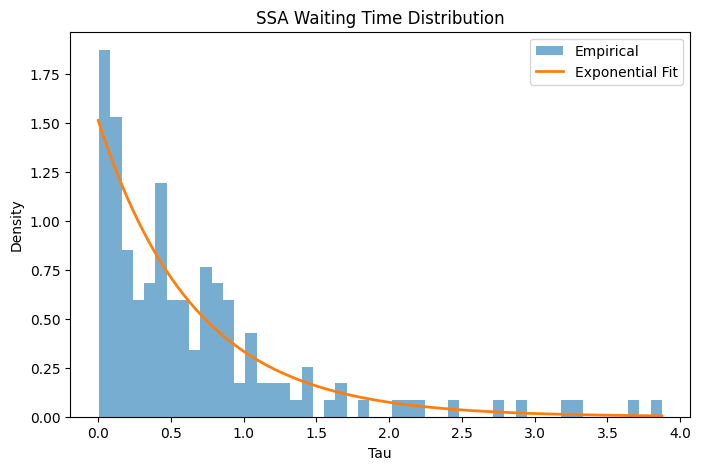

In [9]:
import numpy as np
import matplotlib.pyplot as plt

sim = gillespy2.Simulation(model, "SSA")
sim.reset()

# Run one long trajectory to collect many tau samples
sim.run_until(100)

taus = np.array(sim.solver._tau_samples)

plt.figure(figsize=(8,5))
plt.hist(taus, bins=50, density=True, alpha=0.6, label="Empirical")

# Fit exponential distribution
lambda_hat = 1 / np.mean(taus)
x = np.linspace(0, max(taus), 200)

plt.plot(x, lambda_hat * np.exp(-lambda_hat * x),
         linewidth=2, label="Exponential Fit")

plt.xlabel("Tau")
plt.ylabel("Density")
plt.title("SSA Waiting Time Distribution")
plt.legend()
plt.show()


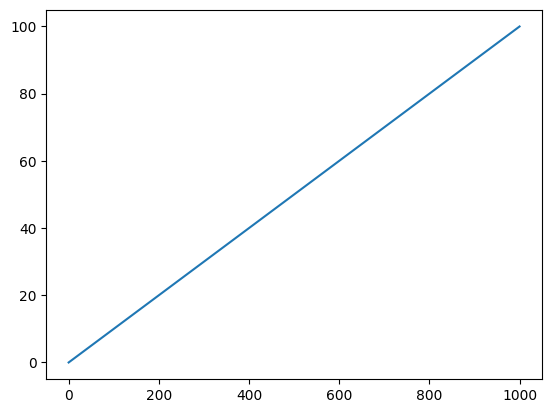

In [10]:
plt.plot(times)